In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('BostonHousing.csv')
print(df.head())
df.dropna()
df.fillna({
    'chas' : df['chas'].median(),
    'zn' : df['zn'].mean(),
    'indus' : df['indus'].mean(),
    'age' : df['age'].mean(),
    'lstat' : df['lstat'].mean(),
    'medv' : df['medv'].mean(),
    'crim' : df['crim'].mean()
}, inplace=True)

df.dropna(inplace=True)
x = df.drop('medv', axis=1)
y = df['medv']

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(y_pred)
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("R2 score: ", r2_score(y_test, y_pred))


[10.18296392 22.90028638 15.7250715  32.8687425  23.06305477 11.7105764
 12.82823273 19.68402832 21.37844603 11.6664091  18.68922207 30.07985757
 -1.00929105 25.84534881  2.71769491  8.42105272 24.20065448 18.58158855
 25.35750486 -6.4156406  13.40087749 19.1553702  26.97331835 19.7365225
 22.34723932 16.49474319 28.88299512 25.84032247 18.44473853 21.44179917
 20.47924119 30.65762986 18.03142754 31.7042724  31.32197253 22.39925592
  7.89877816 23.82379177  8.79518229 24.80967266 13.11828624 36.50280369
 14.21716209 30.64314489 13.08150701 28.62892717 30.41900005 20.22002346
 18.50467142 13.74969166 24.00007979 33.05373811 16.31792202 11.83136693
 34.38516527 33.21409913 17.58969598 18.73951491 15.77944095 27.36843691
 20.56962491 41.00811461 20.7069354   7.90355031 26.05404575 28.09290827
 11.99510305  7.63645472 27.23768211 16.49955956 23.31864783 14.72891378
 40.15780832 28.66567671 23.21450156 23.90785079 35.44266626 24.54286797
 20.92244781 16.20464352 27.10551186 28.05804536 21.2

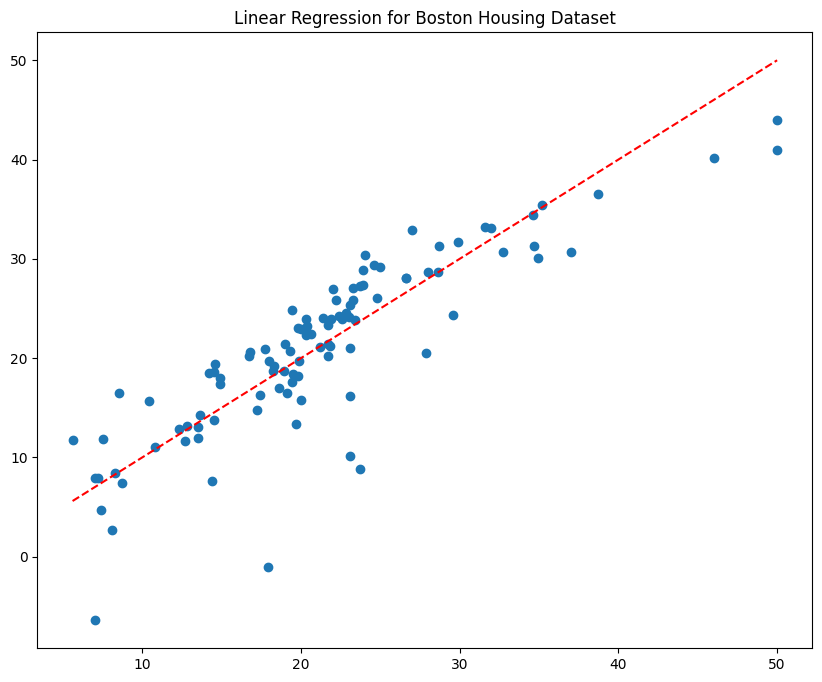

In [5]:
plt.figure(figsize = (10,8))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression for Boston Housing Dataset")
plt.show()